In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv('D:\\depi ml\\src\\session_8\\assignment\\insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
def chk_types(df):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    return pd.DataFrame({"Dtype": dtypes, "Num_Uniqe": n_uniq}).T

In [7]:
chk_types(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
Num_Uniqe,47,2,548,6,2,4,1337


In [10]:
cols = ['sex',
        'smoker',
        'region']
df[cols] = df[cols].astype('category')

In [13]:
df.shape[0]

1338

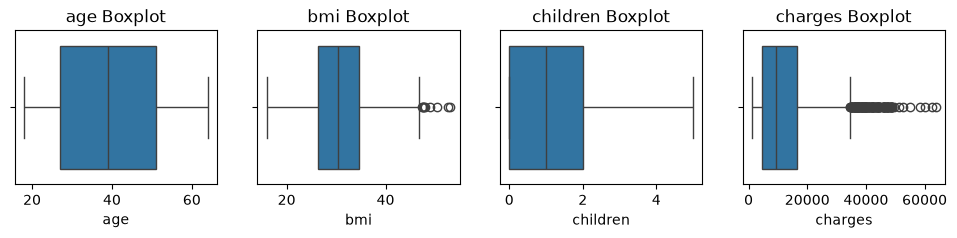

In [21]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(12, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [20]:
num_cols = ['age', 'bmi', 'charges']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

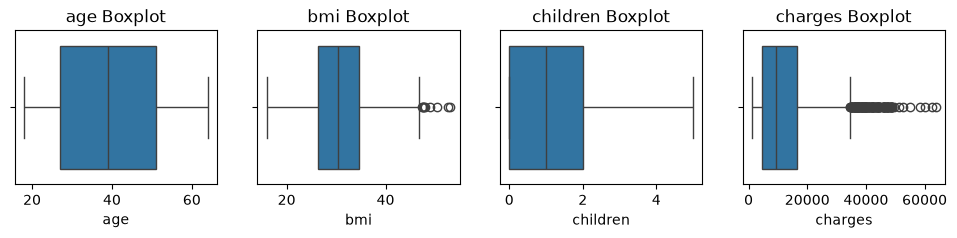

In [22]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(12, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [25]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

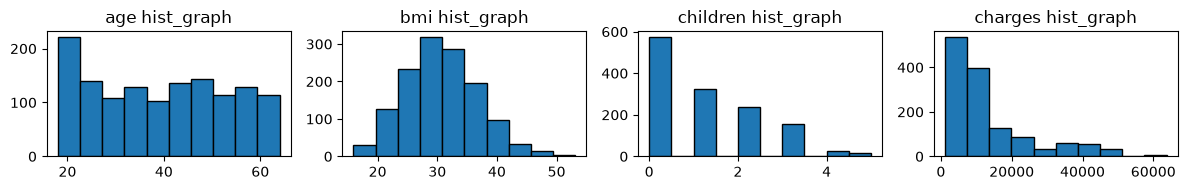

In [26]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(12,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.tight_layout()
plt.show()

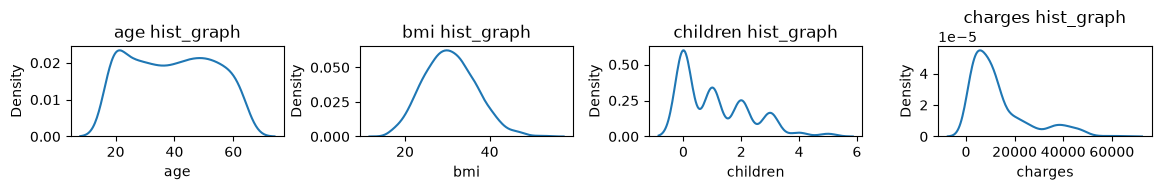

In [27]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(12, 2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.tight_layout()
plt.show()

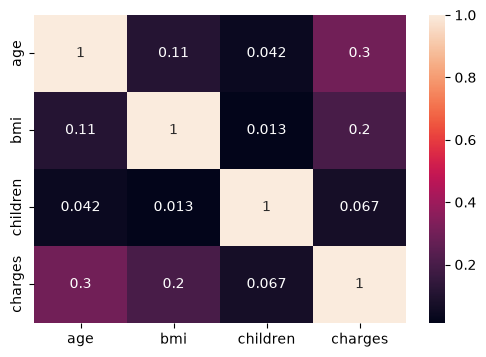

In [28]:
num_cols = df.select_dtypes('number').columns
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True)
plt.show()

In [30]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index([], dtype='str')

In [ ]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(12, 3))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=col,data=df)
    plt.title(f"{col} countplot")
plt.tight_layout()
plt.show()

<Figure size 1200x300 with 0 Axes>

In [33]:
unique = df['sex'].value_counts()
count = unique.values
print(unique)
print(count)

sex
male      675
female    662
Name: count, dtype: int64
[675 662]


In [36]:
cat_cols = ['sex', 'smoker', 'region']
df[cat_cols] = df[cat_cols].astype('category')

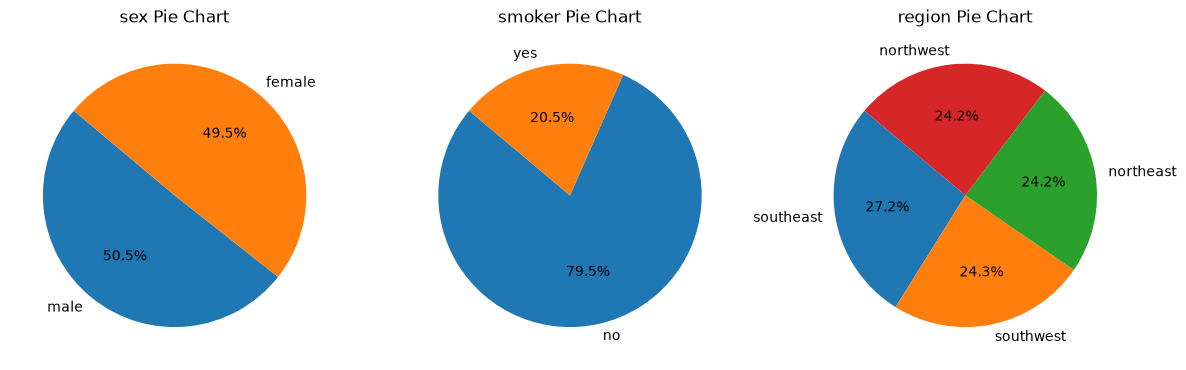

In [37]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(12, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, startangle=140, autopct='%1.1f%%')
    plt.title(f"{col} Pie Chart")

plt.tight_layout()
plt.show()

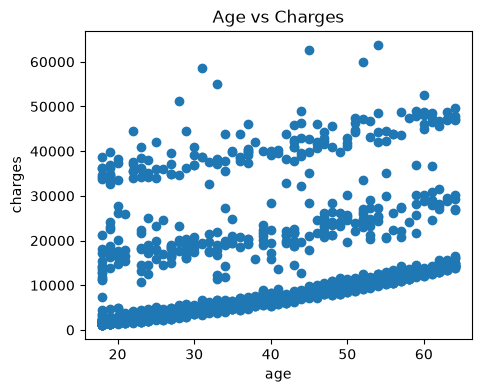

In [38]:
plt.figure(figsize=(5, 4))
plt.scatter(df['age'], df['charges'])
plt.xlabel("age")
plt.ylabel("charges")
plt.title("Age vs Charges")
plt.show()

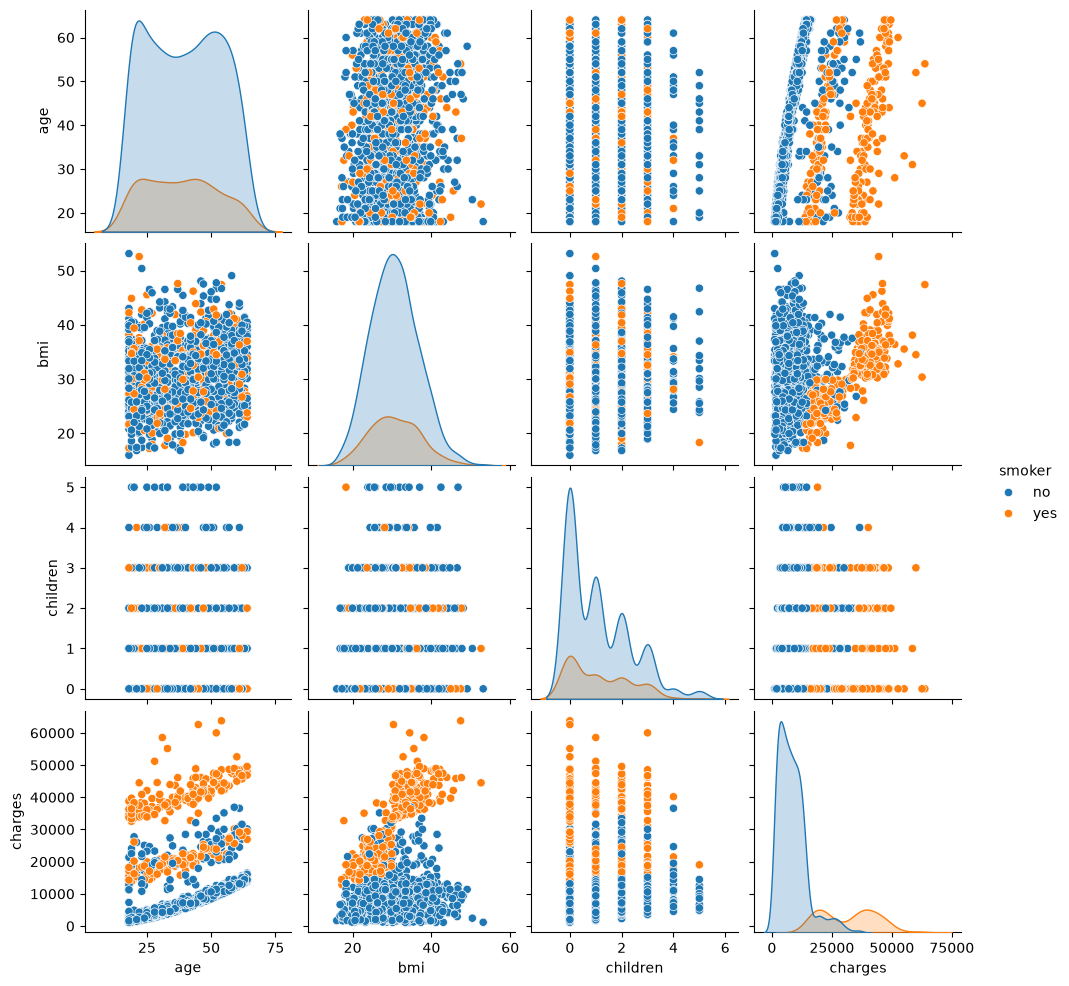

In [40]:
sns.pairplot(df, hue='smoker')
plt.show()

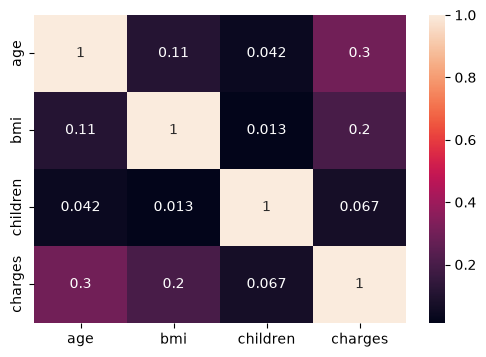

In [41]:
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True)
plt.show()

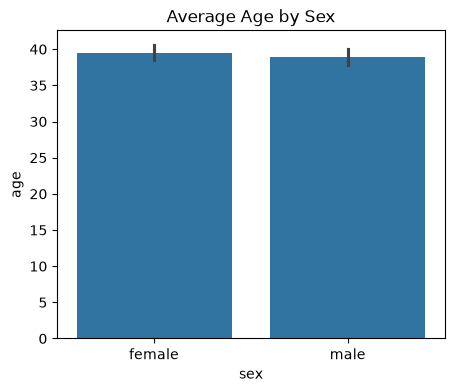

In [42]:
plt.figure(figsize=(5, 4))
sns.barplot(x="sex", y="age", data=df)
plt.title("Average Age by Sex")
plt.show()

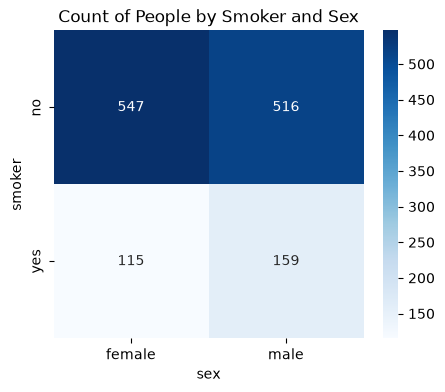

In [43]:
plt.figure(figsize=(5, 4))
agg = df.pivot_table(index="smoker", columns="sex", values="charges", aggfunc=len)
sns.heatmap(agg, annot=True, fmt="d", cmap="Blues")
plt.title("Count of People by Smoker and Sex")
plt.show()